In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

#Feature Engineering
Feature Engineering is the process of creating new meaningful variables (features) from existing data to improve analysis and model performance.

In [4]:
df = pd.read_csv("irrigation_prediction.csv")

In [6]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [7]:
#Moisture Level Category

In [8]:
df['Moisture_Level'] = pd.cut(df['Soil_Moisture'],
                             bins=[0,30,60,100],
                             labels=['Low','Medium','High'])

In [9]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'Moisture_Level'],
      dtype='object')

In [10]:
#Temperature Level

In [11]:
df['Temp_Level'] = pd.cut(df['Temperature_C'],
                         bins=[0,20,30,50],
                         labels=['Low','Medium','High'])

In [23]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'Moisture_Level', 'Temp_Level', 'Rainfall_Level', 'Moisture_Deficit',
       'Temp_Moisture_Interaction', 'Irrigation_Score'],
      dtype='object')

In [12]:
#Rainfall Category

In [13]:
df['Rainfall_Level'] = pd.cut(df['Rainfall_mm'],
                             bins=[0,500,1000,2000],
                             labels=['Low','Medium','High'])

In [24]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'Moisture_Level', 'Temp_Level', 'Rainfall_Level', 'Moisture_Deficit',
       'Temp_Moisture_Interaction', 'Irrigation_Score'],
      dtype='object')

In [14]:
#Soil Moisture Deficit

In [15]:
df['Moisture_Deficit'] = 100 - df['Soil_Moisture']

In [16]:
#Interaction Feature

In [17]:
df['Temp_Moisture_Interaction'] = df['Temperature_C'] * df['Soil_Moisture']

In [27]:
df['Temp_Moisture_Interaction']

0        798.9120
1       1845.4400
2       1676.1281
3        474.5550
4        415.8204
          ...    
9995     736.3587
9996    1682.4432
9997    2223.9084
9998    1396.3950
9999    2222.9475
Name: Temp_Moisture_Interaction, Length: 10000, dtype: float64

In [18]:
#Encode Categorical Data

In [19]:
df_encoded = pd.get_dummies(df, columns=['Soil_Type','Crop_Type','Season'])

In [30]:
df_encoded

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Growth_Stage,...,Soil_Type_Silt,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,Season_Kharif,Season_Rabi,Season_Zaid
0,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Vegetative,...,False,False,False,False,False,False,True,False,True,False
1,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Flowering,...,True,False,True,False,False,False,False,False,False,True
2,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Harvest,...,False,True,False,False,False,False,False,False,True,False
3,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Sowing,...,False,False,False,False,False,False,True,True,False,False
4,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Sowing,...,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7.01,26.67,0.86,0.76,27.61,52.20,1075.12,7.41,19.66,Sowing,...,True,False,False,False,False,True,False,True,False,False
9996,5.40,49.44,0.90,1.19,34.03,52.31,1591.84,9.86,5.66,Sowing,...,False,False,True,False,False,False,False,True,False,False
9997,4.97,60.63,0.99,1.30,36.68,68.16,2384.87,10.75,13.40,Harvest,...,False,False,False,True,False,False,False,True,False,False
9998,7.12,44.33,1.56,1.08,31.50,64.83,2397.01,4.03,3.05,Harvest,...,False,False,False,False,False,True,False,True,False,False


In [20]:
#Irrigation Score

In [31]:
df['Irrigation_Score'] = (
    df['Moisture_Deficit'] * 0.5 +
    df['Temperature_C'] * 0.3 -
    df['Rainfall_mm'] * 0.2
)

In [32]:
df['Irrigation_Score']

0      -195.210
1      -130.586
2      -326.376
3        -6.461
4      -327.702
         ...   
9995   -170.076
9996   -282.879
9997   -446.285
9998   -442.117
9999     -5.950
Name: Irrigation_Score, Length: 10000, dtype: float64

In [22]:
#Visualization

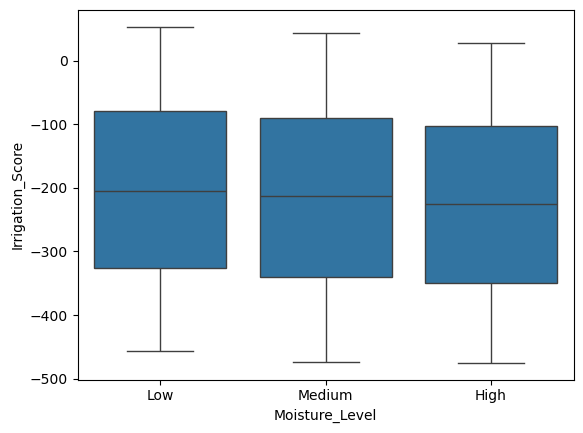

In [33]:
sns.boxplot(x='Moisture_Level', y='Irrigation_Score', data=df)
plt.show()

Insights
1)Soil moisture was categorized into levels
2)Temperature and rainfall were converted into categories
3)A moisture deficit feature was created to measure water requirement
4)Interaction features were used to capture combined effects
5)An irrigation score was developed for better decision making